# Soil Texture from Spectra

**GeoAI LAB** - predicting sand, silt and clay from VisNIR reflectance spectra.

Needs only the three CSVs beside it. Runs top to bottom. Each cell is labelled with the
task it answers.

Sections: 0 setup | 1 exploration (1.1-1.15) | 2 sensors (2.1-2.5) | 3 before modelling
(3.1-3.3) | 4 first model (4.1-4.4) | 5 validation (5.1-5.4) | 6 explainability (6.1-6.6)

## 0 - Setup

Two things found in 1.2 that shape everything after:

- **`L400`-`L450` is missing for all 22 171 LUCAS rows.** Their instrument starts at 455 nm.
  So I use `SPEC` (421 columns) for the plots, and `SPEC410` (455-2500 nm) for the calculations.
- **Two rows are dead spectra.** Their reflectance is 1.0 everywhere. `VALID` removes them.

In [1]:
# setup
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dataset = pd.read_csv("ossl_tp_dataset.csv", low_memory=False)
soillab = pd.read_csv("ossl_tp_soillab.csv", low_memory=False)
soilsite = pd.read_csv("ossl_tp_soilsite.csv", low_memory=False)

SPEC = sorted([c for c in dataset.columns if re.fullmatch(r"L\d+", c)], key=lambda c: int(c[1:]))
WL = np.array([int(c[1:]) for c in SPEC])
META = [c for c in dataset.columns if c not in SPEC]
TARGETS = ["sand", "silt", "clay"]
PROGS = ["ICRAF.ISRIC", "KSSL.SSL", "LUCAS.SSL"]
COLORS = {"ICRAF.ISRIC": "#1b7f79", "KSSL.SSL": "#c1553b", "LUCAS.SSL": "#3d5a99",
          "sand": "#c98b3b", "silt": "#4a8c6f", "clay": "#8c4a6f"}

A = dataset[SPEC].to_numpy()                       # spectra, with NaN
SPEC410 = [c for c in SPEC if dataset[c].notna().all()]
WL410 = np.array([int(c[1:]) for c in SPEC410])
VALID = np.nanstd(A, axis=1) > 0                   # False for the two dead spectra
X = dataset.loc[VALID, SPEC410].to_numpy()         # clean matrix used for all maths

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 130, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})

def save_fig(task):
    plt.savefig(f"figs/fig_{task.replace('.', '_')}.png")

print(f"SPEC {len(SPEC)} columns | SPEC410 {len(SPEC410)} columns | dead rows {(~VALID).sum()}")

SPEC 421 columns | SPEC410 410 columns | dead rows 2


## 1 - Data exploration

### 1.1 - Size and columns &nbsp;&nbsp;|&nbsp;&nbsp; 1.2 - Missing values, duplicates, ranges

**Deliverables:** shape + column list; 1 summary table.

In [2]:
# tasks 1.1 and 1.2
print("dataset ", dataset.shape, " soillab", soillab.shape, " soilsite", soilsite.shape)
print("metadata:", META)
print("spectra :", SPEC[0], "..", SPEC[-1], "- reflectance every 5 nm\n")

summary = dataset[META].describe(include="all").T[["count", "min", "max"]]
summary["missing"] = dataset[META].isna().sum()
summary.loc["L400-L450 (11 cols)"] = [len(dataset) * 11 - np.isnan(A[:, :11]).sum(),
                                      np.nanmin(A[:, :11]), np.nanmax(A[:, :11]),
                                      np.isnan(A[:, :11]).sum()]
summary.loc["L455-L2500 (410 cols)"] = [len(dataset) * 410, np.nanmin(X), np.nanmax(X), 0]
summary.to_csv("tables/table_1_2.csv")
summary

dataset  (40535, 433)  soillab (40535, 58)  soilsite (40535, 36)
metadata: ['id', 'programme', 'instrument', 'prof_haut', 'prof_bas', 'sand', 'silt', 'clay', 'classe_usda', 'lon', 'lat', 'n_scans']
spectra : L400 .. L2500 - reflectance every 5 nm



,count,min,max,missing
id,40535,NaN,NaN,0.0
programme,40535,NaN,NaN,0.0
instrument,40535,NaN,NaN,0.0
prof_haut,40535.0,0.0,278.0,0.0
prof_bas,40535.0,1.0,300.0,0.0
sand,40535.0,0.0,100.0,0.0
silt,40535.0,0.0,94.4806,0.0
clay,40535.0,0.0,96.8969,0.0
classe_usda,40535,NaN,NaN,0.0
lon,40037.0,-172.3633,153.017,498.0


In [3]:
# task 1.2: duplicates and ranges
print("duplicate ids     :", dataset["id"].duplicated().sum())
print("duplicate spectra :", dataset.duplicated(subset=SPEC).sum(),
      "- but 0 once targets are included, so they carry different texture values")
print("reflectance range :", np.nanmin(A).round(3), "-", np.nanmax(A).round(3))
print("dead spectra      :", (~VALID).sum(), "rows have reflectance 1.0 at every wavelength")
print("missing lon/lat   :", dataset["lon"].isna().sum())
print("missing L400      :", dataset["L400"].isna().sum(), "- all of them LUCAS")

duplicate ids     : 0


duplicate spectra : 11 - but 0 once targets are included, so they carry different texture values
reflectance range : 0.02 - 1.0
dead spectra      : 2 rows have reflectance 1.0 at every wavelength
missing lon/lat   : 498
missing L400      : 22171 - all of them LUCAS


### 1.3 - Twenty spectra &nbsp;|&nbsp; 1.4 - Mean ±1 SD &nbsp;|&nbsp; 1.5 - Mean per programme

**Deliverables:** 3 figures. The grey band marks the wavelengths LUCAS does not measure.

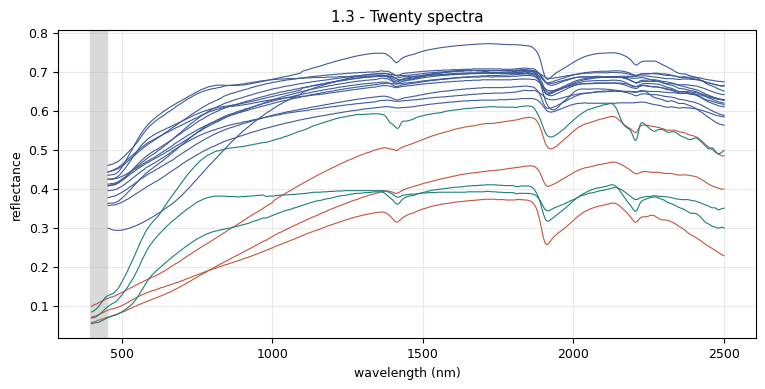

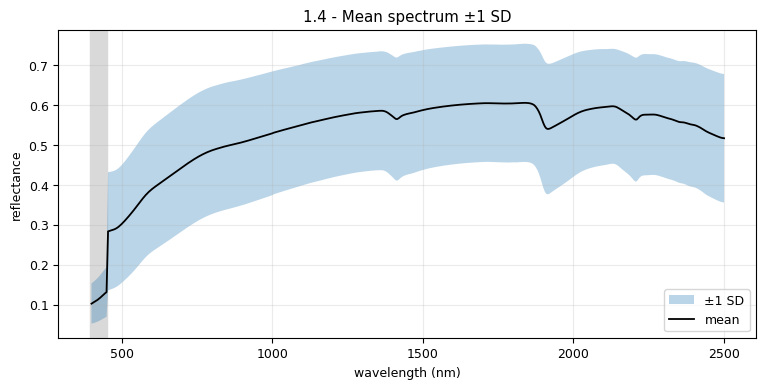

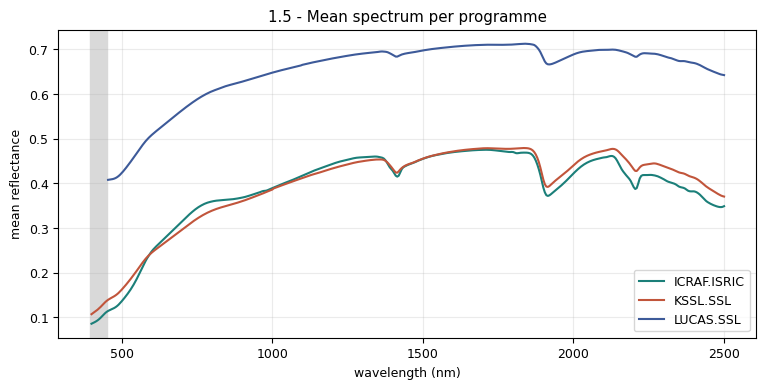

instrument   ASD_FieldSpec  ASD_LabSpec    XDS
programme                                     
ICRAF.ISRIC           3636            0      0
KSSL.SSL                 0        14728      0
LUCAS.SSL                0            0  22171
-> each programme used exactly one instrument, so I cannot separate them.


In [4]:
# 1.3: twenty spectra
idx = np.random.default_rng(0).choice(len(dataset), 20, replace=False)
plt.figure(figsize=(9, 4))
for i in idx:
    plt.plot(WL, A[i], lw=0.8, color=COLORS[dataset["programme"].iloc[i]])
plt.axvspan(395, 452, color="0.85", zorder=0)
plt.xlabel("wavelength (nm)"); plt.ylabel("reflectance"); plt.title("1.3 - Twenty spectra")
save_fig("1.3"); plt.show()

# 1.4:  mean and sd
mean, sd = np.nanmean(A, axis=0), np.nanstd(A, axis=0)
plt.figure(figsize=(9, 4))
plt.fill_between(WL, mean - sd, mean + sd, alpha=0.3, label="±1 SD")
plt.plot(WL, mean, color="black", lw=1.3, label="mean")
plt.axvspan(395, 452, color="0.85", zorder=0)
plt.xlabel("wavelength (nm)"); plt.ylabel("reflectance"); plt.legend()
plt.title("1.4 - Mean spectrum ±1 SD"); save_fig("1.4"); plt.show()

# 1.5: one curve per programme
means = dataset.groupby("programme")[SPEC].mean()
plt.figure(figsize=(9, 4))
for p in PROGS:
    plt.plot(WL, means.loc[p], color=COLORS[p], label=p)
plt.axvspan(395, 452, color="0.85", zorder=0)
plt.xlabel("wavelength (nm)"); plt.ylabel("mean reflectance"); plt.legend()
plt.title("1.5 - Mean spectrum per programme"); save_fig("1.5"); plt.show()

print(pd.crosstab(dataset["programme"], dataset["instrument"]))
print("-> each programme used exactly one instrument, so I cannot separate them.")

### 1.6 - PCA &nbsp;&nbsp;|&nbsp;&nbsp; 1.7 - Correlation between neighbouring wavelengths

**Deliverables:** number of components reaching 95%; 1 number.

PCA cannot use columns with NaN, so I ran it on `SPEC410`. I centred the data but did not
standardise it, because all columns are reflectance in the same unit.

ANSWER 1.6: 1 component reaches 95% of the variance
  PC1 alone = 95.43 %
  PC1's loadings all have the same sign -> PC1 is brightness, not texture

ANSWER 1.7: r(L1000, L1005) = 0.999944
  neighbouring wavelengths are almost the same, so 1 component is enough


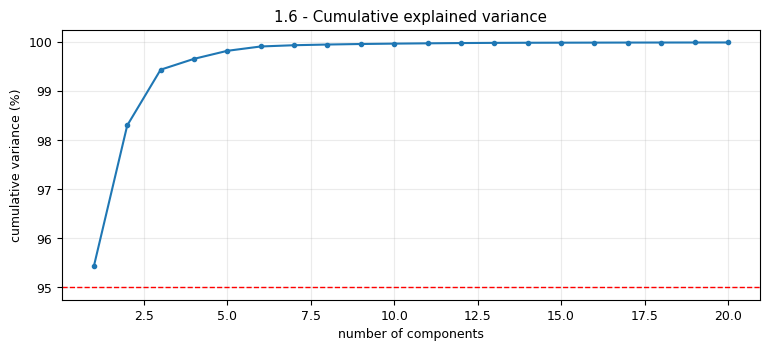

In [5]:
from sklearn.decomposition import PCA

pca = PCA().fit(X)
cumulative = np.cumsum(pca.explained_variance_ratio_)
n95 = np.argmax(cumulative >= 0.95) + 1
print("ANSWER 1.6:", n95, "component reaches 95% of the variance")
print("  PC1 alone =", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("  PC1's loadings all have the same sign -> PC1 is brightness, not texture")

r = np.corrcoef(dataset["L1000"], dataset["L1005"])[0, 1]
print("\nANSWER 1.7: r(L1000, L1005) =", round(r, 6))
print("  neighbouring wavelengths are almost the same, so 1 component is enough")

plt.figure(figsize=(9, 3.5))
plt.plot(range(1, 21), cumulative[:20] * 100, marker="o", ms=3)
plt.axhline(95, color="red", ls="--", lw=1)
plt.xlabel("number of components"); plt.ylabel("cumulative variance (%)")
plt.title("1.6 - Cumulative explained variance"); save_fig("1.6"); plt.show()

### 1.8 - Distributions &nbsp;|&nbsp; 1.9 - Sum of fractions &nbsp;|&nbsp; 1.10 - Texture triangle &nbsp;|&nbsp; 1.11 - Class counts

**Deliverables:** 1 figure; min/mean/max; 1 figure; 1 table.

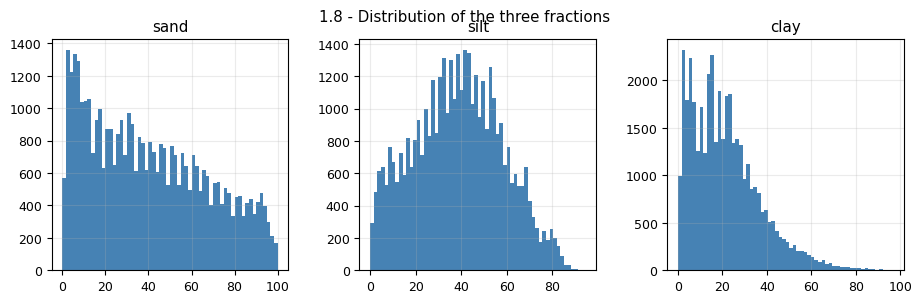

           sand      silt      clay
count  40535.00  40535.00  40535.00
mean      40.05     38.56     21.39
std       27.35     19.39     15.38
min        0.00      0.00      0.00
25%       15.90     24.01      9.09
50%       36.36     38.82     19.00
75%       61.09     52.53     29.97
max      100.00     94.48     96.90

ANSWER 1.9: min 99.9999  mean 100.0  max 100.0001
  The fractions already sum to 100 (not to 1), so only two of them are free.
  Task 4.3's '2% from 1' therefore means 2 points away from 100.


In [6]:
# tasks 1.8 and 1.9
dataset[TARGETS].hist(bins=60, figsize=(11, 3), layout=(1, 3), color="steelblue")
plt.suptitle("1.8 - Distribution of the three fractions")
save_fig("1.8"); plt.show()
print(dataset[TARGETS].describe().round(2))

total = dataset[TARGETS].sum(axis=1)
print("\nANSWER 1.9: min", round(total.min(), 4), " mean", round(total.mean(), 4),
      " max", round(total.max(), 4))
print("  The fractions already sum to 100 (not to 1), so only two of them are free.")
print("  Task 4.3's '2% from 1' therefore means 2 points away from 100.")

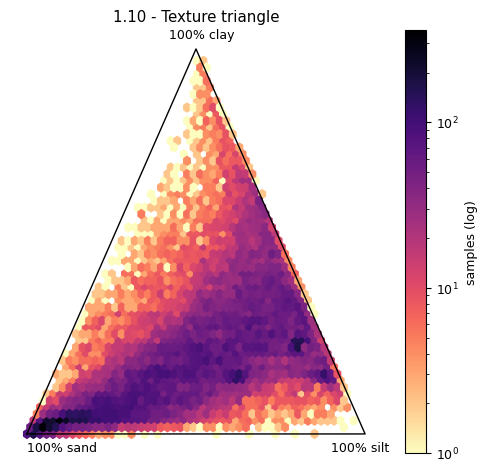

ANSWER 1.11: 12 classes, largest/smallest = 57 x


classe_usda
Silt loam          7847
Sandy loam         7660
Loam               6488
Silty clay loam    4070
Clay loam          2955
Clay               2773
Sand               2660
Loamy sand         2617
Silty clay         2019
Sandy clay loam    1163
Silt                146
Sandy clay          137
Name: count, dtype: int64

In [7]:
# tasks 1.10 and 1.11
x = 0.5 * (2 * dataset["silt"] + dataset["clay"]) / 100
y = (np.sqrt(3) / 2) * dataset["clay"] / 100

plt.figure(figsize=(6, 5.5))
plt.hexbin(x, y, gridsize=50, bins="log", cmap="magma_r", mincnt=1)
plt.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3) / 2, 0], color="black", lw=1)
plt.colorbar(label="samples (log)")
plt.text(0, -0.04, "100% sand"); plt.text(0.9, -0.04, "100% silt"); plt.text(0.42, 0.89, "100% clay")
plt.axis("off"); plt.title("1.10 - Texture triangle")
save_fig("1.10"); plt.show()

counts = dataset["classe_usda"].value_counts()
counts.to_csv("tables/table_1_11.csv")
print("ANSWER 1.11:", len(counts), "classes, largest/smallest =",
      round(counts.max() / counts.min()), "x")
counts

### 1.12 - Map &nbsp;|&nbsp; 1.13 - Samples and clay per programme &nbsp;|&nbsp; 1.14 - Depth

**Deliverables:** 1 figure; 1 table + 1 figure; 1 figure.

These three figures show that `programme` is also a region and a sampling depth.

dropped 498 rows with no coordinates


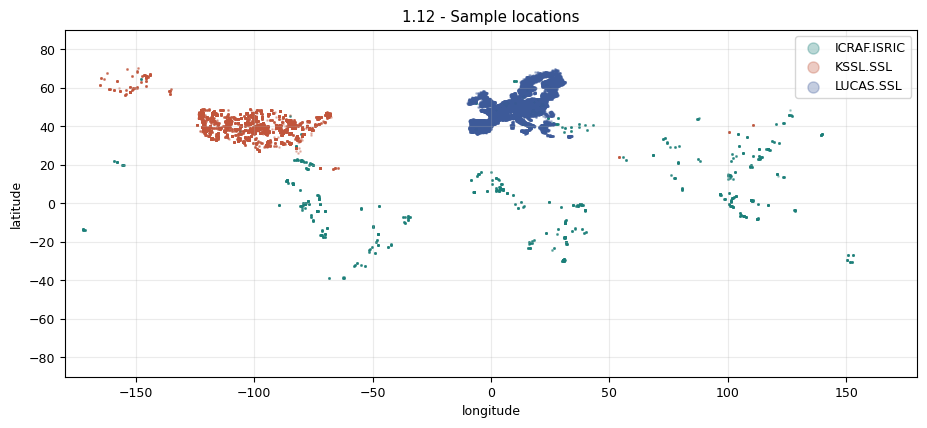

In [8]:
geo = dataset.dropna(subset=["lon", "lat"])
print("dropped", len(dataset) - len(geo), "rows with no coordinates")

plt.figure(figsize=(11, 4.5))
for p in PROGS:
    g = geo[geo["programme"] == p]
    plt.scatter(g["lon"], g["lat"], s=1, alpha=0.3, color=COLORS[p], label=p)
plt.xlim(-180, 180); plt.ylim(-90, 90); plt.xlabel("longitude"); plt.ylabel("latitude")
plt.legend(markerscale=8); plt.title("1.12 - Sample locations")
save_fig("1.12"); plt.show()

programme
LUCAS.SSL      22171
KSSL.SSL       14728
ICRAF.ISRIC     3636
Name: count, dtype: int64 



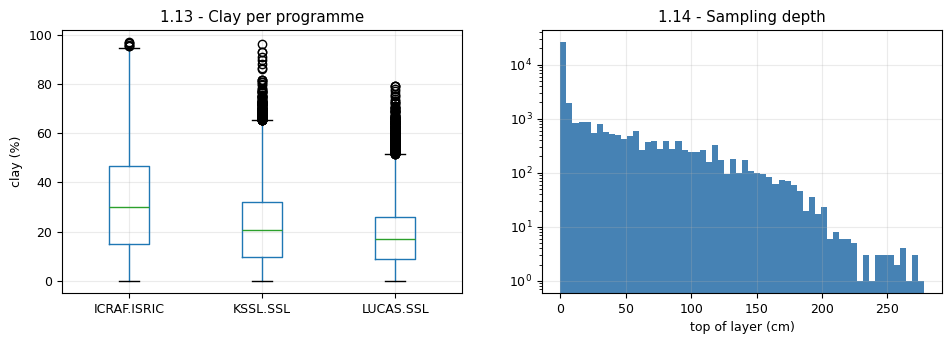

programme
ICRAF.ISRIC    40.0
KSSL.SSL       25.0
LUCAS.SSL       0.0
Name: prof_haut, dtype: float64
-> LUCAS samples the surface, ICRAF goes deeper, so the depth is also different.


In [9]:
table = dataset.groupby("programme")[["clay"]].describe().round(1)
table.to_csv("tables/table_1_13.csv")
print(dataset["programme"].value_counts(), "\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
dataset.boxplot(column="clay", by="programme", ax=ax1)
ax1.set_title("1.13 - Clay per programme"); ax1.set_xlabel(""); ax1.set_ylabel("clay (%)")
dataset["prof_haut"].hist(bins=60, ax=ax2, color="steelblue")
ax2.set_yscale("log"); ax2.set_title("1.14 - Sampling depth"); ax2.set_xlabel("top of layer (cm)")
plt.suptitle("")
save_fig("1.13"); save_fig("1.14")   # one figure, but both tasks ask for one
plt.show()

print(dataset.groupby("programme")["prof_haut"].median())
print("-> LUCAS samples the surface, ICRAF goes deeper, so the depth is also different.")

### 1.15 - Correlation of every wavelength with each target

**Deliverable:** 1 figure + the peak wavelength of each target.

The peak is taken on **|r|**, because clay correlates negatively over most of the range.
The second figure repeats the same calculation inside each programme.

ANSWER 1.15 - peak |r| per target (all programmes pooled):
  sand  2500 nm   r = +0.074
  silt  2170 nm   r = +0.155
  clay  2500 nm   r = -0.319


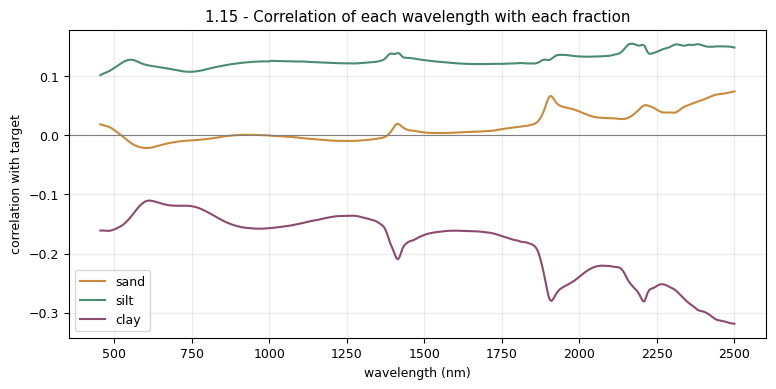

In [10]:
def correlations(rows):
    return np.array([[np.corrcoef(dataset.loc[rows, c], dataset.loc[rows, t])[0, 1]
                      for t in TARGETS] for c in SPEC410])

R = correlations(VALID)

plt.figure(figsize=(9, 4))
print("ANSWER 1.15 - peak |r| per target (all programmes pooled):")
for k, t in enumerate(TARGETS):
    plt.plot(WL410, R[:, k], color=COLORS[t], label=t)
    best = np.argmax(abs(R[:, k]))
    print(f"  {t:5s} {WL410[best]} nm   r = {R[best, k]:+.3f}")
plt.axhline(0, color="grey", lw=0.8); plt.legend()
plt.xlabel("wavelength (nm)"); plt.ylabel("correlation with target")
plt.title("1.15 - Correlation of each wavelength with each fraction")
save_fig("1.15"); plt.show()

ICRAF.ISRIC  sand  peak 1910 nm  r = +0.359
ICRAF.ISRIC  silt  peak 2205 nm  r = +0.198
ICRAF.ISRIC  clay  peak 2475 nm  r = -0.606


KSSL.SSL     sand  peak 1275 nm  r = -0.060
KSSL.SSL     silt  peak 2500 nm  r = +0.199
KSSL.SSL     clay  peak 2500 nm  r = -0.361


LUCAS.SSL    sand  peak 605 nm  r = -0.369
LUCAS.SSL    silt  peak 625 nm  r = +0.358
LUCAS.SSL    clay  peak 605 nm  r = +0.237


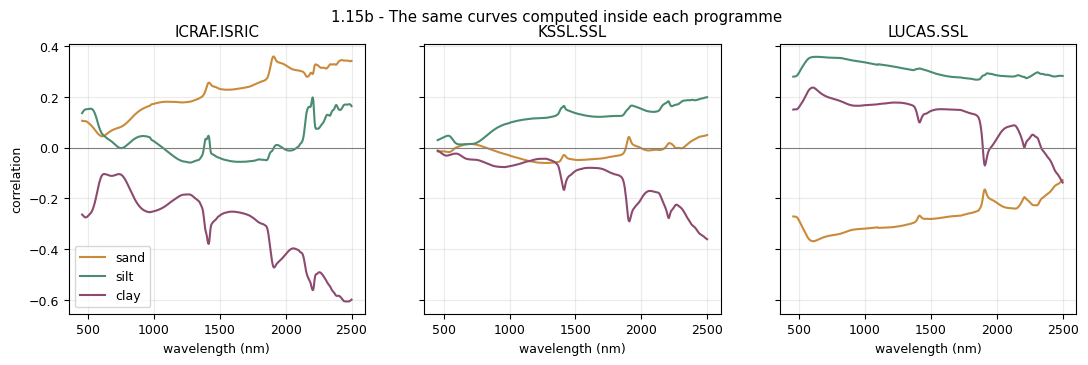

In [11]:
# 1.15
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, p in zip(axes, PROGS):
    Rp = correlations(VALID & (dataset["programme"] == p))
    for k, t in enumerate(TARGETS):
        ax.plot(WL410, Rp[:, k], color=COLORS[t], label=t)
        print(f"{p:12s} {t:5s} peak {WL410[np.argmax(abs(Rp[:, k]))]} nm  "
              f"r = {Rp[np.argmax(abs(Rp[:, k])), k]:+.3f}")
    ax.axhline(0, color="grey", lw=0.8); ax.set_title(p); ax.set_xlabel("wavelength (nm)")
axes[0].set_ylabel("correlation"); axes[0].legend()
plt.suptitle("1.15b - The same curves computed inside each programme")
save_fig("1.15b"); plt.show()

### Section 1 - answers

| Task | Answer |
|---|---|
| 1.6 | **1 component** reaches 95% (PC1 = 95.4%, and PC1 is brightness, not texture) |
| 1.7 | **r(L1000, L1005) = 0.999944** |
| 1.9 | min **99.9999**, mean **100.0000**, max **100.0001** - closed to 100 |
| 1.15 | sand **2500 nm** (+0.074), silt **2170 nm** (+0.155), clay **2500 nm** (-0.319) |

**Notes for the next sections**

1. I use `SPEC410` (455-2500 nm) for the models, and I remove the two dead rows.
2. `programme` is also the instrument, the region and the depth. Task 5.1 changes all of
   them at once, so I cannot say which one causes the drop.
3. One component holds 95% of 410 columns. So using 12 or 175 bands in section 2 loses less
   than the number of columns suggests.
4. The targets already sum to 100. Any gap in task 4.3 comes only from fitting the three
   fractions separately.

## 2 - Sensor simulation

A laboratory spectrometer returns a continuous curve; a satellite returns one number per
band. This section produces what two satellites would have measured for these same soils.

### 2.1 - The 12 multispectral bands &nbsp;|&nbsp; 2.2 - Bands every 12 nm

**Deliverables:** 1 table with 12 columns + the rule used; 1 table with ~175 columns.

The rule is in `resample()` below: each band is the plain average of every laboratory
wavelength inside `centre ± width/2`. If a band contains a missing wavelength, the result is
NaN. I did not want a band computed from only half of its window.

In [12]:
# tasks 2.1 and 2.2: simulate the two sensors
BANDS_12 = [("B1", 443, 20), ("B2", 490, 65), ("B3", 560, 35), ("B4", 665, 30),
            ("B5", 705, 15), ("B6", 740, 15), ("B7", 783, 20), ("B8", 842, 115),
            ("B8A", 865, 20), ("B9", 945, 20), ("B11", 1610, 90), ("B12", 2190, 180)]

# 12 nm wide
BANDS_HYPER = [(f"H{400 + 12 * k}", 406 + 12 * k, 12) for k in range(175)]

def resample(bands): # one number per band: the mean of the laboratory wavelengths inside it
    out = {}
    for name, centre, width in bands:
        cols = [c for c, w in zip(SPEC, WL) if abs(w - centre) <= width / 2]
        out[name] = dataset[cols].mean(axis=1, skipna=False)
    return pd.DataFrame(out)

multi = resample(BANDS_12)
hyper = resample(BANDS_HYPER)

MULTI_OK = [b for b in multi.columns if multi[b].notna().all()]
HYPER_OK = [b for b in hyper.columns if hyper[b].notna().all()]

print("multispectral:", multi.shape[1], "bands,", len(MULTI_OK), "usable")
print("  B1 covers 433-453 nm, inside the LUCAS gap ->", multi["B1"].isna().sum(), "rows are NaN")
print("hyperspectral:", hyper.shape[1], "bands,", len(HYPER_OK), "usable")
print("  unusable:", [b for b in hyper.columns if b not in HYPER_OK])
print("\nModels in sections 4-6 therefore use 11 and 170 bands, not 12 and 175.")

multi.head(50).to_csv("tables/table_2_1.csv")
multi.head()

multispectral: 12 bands, 11 usable
  B1 covers 433-453 nm, inside the LUCAS gap -> 22171 rows are NaN
hyperspectral: 175 bands, 170 usable
  unusable: ['H400', 'H412', 'H424', 'H436', 'H448']

Models in sections 4-6 therefore use 11 and 170 bands, not 12 and 175.


,B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12
0,0.096995,0.117672,0.187990,0.292806,0.326957,0.354033,0.376692,0.388680,0.392590,0.410004,0.551634,0.452391
1,0.098342,0.120425,0.208143,0.351631,0.391487,0.421907,0.440555,0.438987,0.436578,0.443980,0.580952,0.439338
2,0.088445,0.108619,0.205079,0.395553,0.438503,0.472847,0.480758,0.454880,0.442138,0.440076,0.594613,0.396373
3,0.104765,0.129628,0.229689,0.456477,0.510050,0.544007,0.550763,0.525744,0.513640,0.518688,0.710175,0.419695
4,0.074370,0.092182,0.177866,0.442711,0.498010,0.534750,0.527737,0.489133,0.472690,0.491176,0.722989,0.461514


### 2.3 - One sample, three ways &nbsp;&nbsp;|&nbsp;&nbsp; 2.4 - Mean spectrum, zoomed on 1900-2500 nm

**Deliverables:** 2 figures.

I zoomed on this region because clay minerals absorb near 2200 nm. Task 1.15 also found
clay's strongest correlation there. The horizontal bars in 2.3 show the width of each
multispectral band. B12 alone is 180 nm.

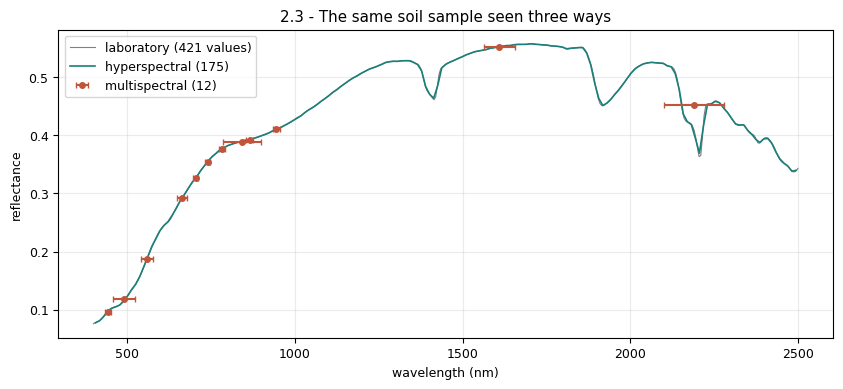

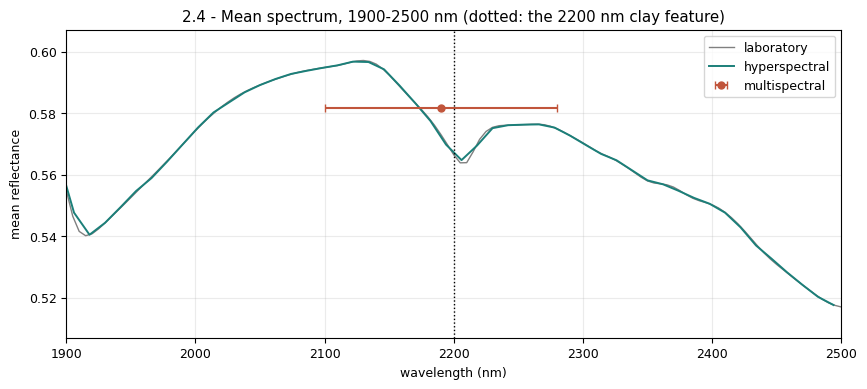

In [13]:
# tasks 2.3 and 2.4: what each sensor would have seen
centres_m = np.array([c for _, c, _ in BANDS_12])
widths_m = np.array([w for _, _, w in BANDS_12])
centres_h = np.array([c for _, c, _ in BANDS_HYPER])

plt.figure(figsize=(10, 4))
plt.plot(WL, A[0], lw=0.8, color="grey", label="laboratory (421 values)")
plt.plot(centres_h, hyper.iloc[0], lw=1.2, color="#1b7f79", label="hyperspectral (175)")
plt.errorbar(centres_m, multi.iloc[0], xerr=widths_m / 2, fmt="o", ms=4, capsize=2,
             color="#c1553b", label="multispectral (12)")
plt.xlabel("wavelength (nm)"); plt.ylabel("reflectance"); plt.legend()
plt.title("2.3 - The same soil sample seen three ways")
save_fig("2.3"); plt.show()

# 2.4 - the mean spectrum, zoomed on the clay absorption region
plt.figure(figsize=(10, 4))
plt.plot(WL, np.nanmean(A, axis=0), lw=1, color="grey", label="laboratory")
plt.plot(centres_h, hyper.mean(), lw=1.4, color="#1b7f79", label="hyperspectral")
plt.errorbar(centres_m, multi.mean(), xerr=widths_m / 2, fmt="o", ms=5, capsize=3,
             color="#c1553b", label="multispectral")
win = (WL >= 1900) & (WL <= 2500)          # scale y to the zoomed window only
lab_mean = np.nanmean(A, axis=0)
plt.xlim(1900, 2500)
plt.ylim(lab_mean[win].min() - 0.01, lab_mean[win].max() + 0.01)
plt.axvline(2200, color="black", ls=":", lw=1)
plt.xlabel("wavelength (nm)"); plt.ylabel("mean reflectance"); plt.legend()
plt.title("2.4 - Mean spectrum, 1900-2500 nm (dotted: the 2200 nm clay feature)")
save_fig("2.4"); plt.show()

In [14]:
# task 2.4: how much of the 2200 nm clay feature each sensor keeps
def feature_depth(values, centres):
    at = lambda w: values[np.argmin(abs(centres - w))]
    return (at(2130) + at(2260)) / 2 - at(2200)

print("depth of the 2200 nm absorption feature")
print("  laboratory   :", round(feature_depth(np.nanmean(A, axis=0), WL), 5))
print("  hyperspectral:", round(feature_depth(hyper.mean().values, centres_h), 5))
print("  multispectral:", round(feature_depth(multi.mean().values, centres_m), 5))
print("\nThe multispectral depth is exactly zero, and not by accident: B12 spans")
print("2100-2280 nm, so the dip and both sides are inside one band. Averaging them")
print("together removes the feature. One number cannot describe a dip.")

depth of the 2200 nm absorption feature
  laboratory   : 0.02029
  hyperspectral: 0.01666
  multispectral: 0.0

The multispectral depth is exactly zero, and not by accident: B12 spans
2100-2280 nm, so the dip and both sides are inside one band. Averaging them
together removes the feature. One number cannot describe a dip.


### 2.5 - The rule, and the alternative rejected

**Deliverable:** 3 written lines.

**Rule.** Each band is the simple mean of every laboratory wavelength inside
`centre ± width/2`. This is a rectangular spectral response. If any wavelength in the window
is missing, the band is NaN.

**Why.** It only needs the band table from the sheet. It keeps the averaging that makes a
wide band useful, because each band here averages 3 to 37 readings. On a regular 5 nm grid,
a simple mean is a fair average of the band.

**Rejected.** A Gaussian response weighted by each band's FWHM is closer to how a real
detector behaves. But the per-band response curves were not supplied, and I did not want to
invent them. I also rejected using the single nearest wavelength. It loses the averaging, and the noise
of one 5 nm channel would go into a band up to 180 nm wide.

## 3 - Before modelling

No model is fitted in this section. The point is to decide what is achievable *before* any
score exists to influence the answer.

### 3.1 - Task 1.15 redone on each simulated sensor &nbsp;|&nbsp; 3.2 - Did the information survive?

**Deliverables:** 1 figure per sensor; a 3x2 table with a reason per cell.

The correlations stay **pooled** across programmes, so they are directly comparable with
task 1.15. Pooling the programmes makes the correlations weaker. Inside one
programme they are 2 to 8 times stronger (see 1.15b).

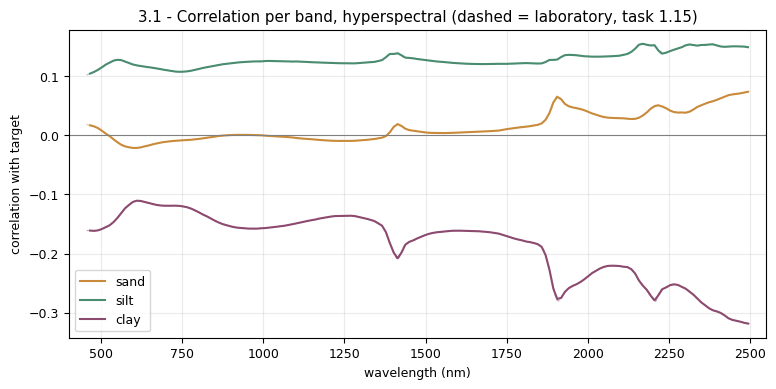

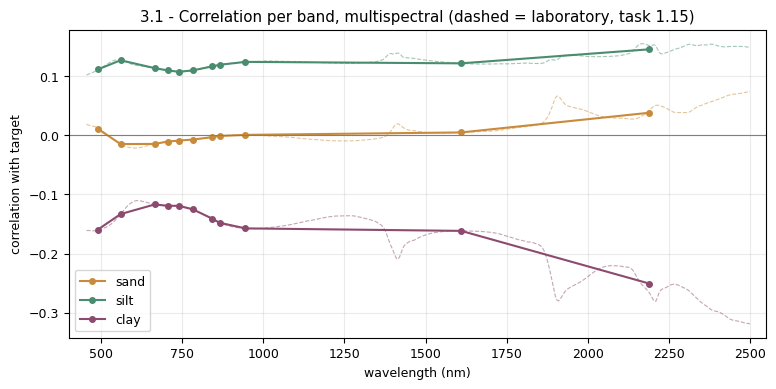

In [15]:
# task 3.1: the same correlation curves, on the simulated sensors
def corr_with_targets(df, cols, rows):
    """Pearson r of each column of df against sand, silt and clay."""
    return np.array([[np.corrcoef(df.loc[rows, c], dataset.loc[rows, t])[0, 1]
                      for t in TARGETS] for c in cols])

R_lab = corr_with_targets(dataset, SPEC410, VALID)
R_hyper = corr_with_targets(hyper, HYPER_OK, VALID)
R_multi = corr_with_targets(multi, MULTI_OK, VALID)

nm_hyper = np.array([c for n, c, w in BANDS_HYPER if n in HYPER_OK])
nm_multi = np.array([c for n, c, w in BANDS_12 if n in MULTI_OK])

for title, R_s, nm, style in [("hyperspectral", R_hyper, nm_hyper, "-"),
                              ("multispectral", R_multi, nm_multi, "o-")]:
    plt.figure(figsize=(9, 4))
    for k, t in enumerate(TARGETS):
        plt.plot(WL410, R_lab[:, k], lw=0.8, ls="--", color=COLORS[t], alpha=0.5)
        plt.plot(nm, R_s[:, k], style, ms=4, color=COLORS[t], label=t)
    plt.axhline(0, color="grey", lw=0.8)
    plt.xlim(400, 2550); plt.legend()
    plt.xlabel("wavelength (nm)"); plt.ylabel("correlation with target")
    plt.title(f"3.1 - Correlation per band, {title} (dashed = laboratory, task 1.15)")
    save_fig(f"3.1_{title}"); plt.show()

In [16]:
# task 3.2: how much of the laboratory correlation each sensor keeps
rows = []
for k, t in enumerate(TARGETS):
    base = abs(R_lab[:, k]).max()
    for sensor, R_s, nm in [("hyperspectral", R_hyper, nm_hyper),
                            ("multispectral", R_multi, nm_multi)]:
        best = np.argmax(abs(R_s[:, k]))
        kept = abs(R_s[best, k]) / base
        rows.append({"target": t, "sensor": sensor,
                     "lab_peak_r": round(base, 3),
                     "sensor_peak_r": round(abs(R_s[best, k]), 3),
                     "peak_nm": nm[best],
                     "kept": round(kept, 2),
                     "survived": "yes" if kept > 0.9 else "partly" if kept > 0.6 else "no"})

table_32 = pd.DataFrame(rows)
table_32.to_csv("tables/table_3_2.csv", index=False)

print("multispectral bands cover:", nm_multi.min(), "-", nm_multi.max(), "nm")
print("laboratory peaks sit at   :",
      {t: int(WL410[np.argmax(abs(R_lab[:, k]))]) for k, t in enumerate(TARGETS)})
table_32

multispectral bands cover: 490 - 2190 nm
laboratory peaks sit at   : {'sand': 2500, 'silt': 2170, 'clay': 2500}


,target,sensor,lab_peak_r,sensor_peak_r,peak_nm,kept,survived
0,sand,hyperspectral,0.074,0.074,2494,0.99,yes
1,sand,multispectral,0.074,0.038,2190,0.51,no
2,silt,hyperspectral,0.155,0.155,2170,1.00,yes
3,silt,multispectral,0.155,0.145,2190,0.94,yes
4,clay,hyperspectral,0.319,0.318,2494,1.00,yes
5,clay,multispectral,0.319,0.251,2190,0.79,partly


#### 3.2 - A reason for every cell

| target | sensor | survived | why |
|---|---|---|---|
| sand | hyperspectral | **yes** (99%) | Sand's peak sits at 2500 nm and the 12 nm grid still samples it, at 2494 nm. Nothing is lost because nothing was narrow. |
| sand | multispectral | **no** (51%) | Sand peaks at **2500 nm, and the multispectral sensor stops at 2280 nm** - the peak region is simply never measured. The best remaining band, B12, carries half the correlation. |
| silt | hyperspectral | **yes** (100%) | Peak kept exactly at 2170 nm. |
| silt | multispectral | **yes** (94%) | By chance, silt's 2170 nm peak falls almost exactly on B12's centre (2190 nm), so one wide band lands right on the signal. |
| clay | hyperspectral | **yes** (100%) | Peak kept at 2494 nm. the 2200 nm feature keeps 82% of its depth (task 2.4). |
| clay | multispectral | **partly** (79%) | Clay loses both of its signals: its 2500 nm peak is out of range, and B12's 180 nm width erases the 2200 nm feature completely (depth 0.0203 -> 0.0000). What survives is not the mineral feature but clay's broad correlation with overall brightness, which any band can see. |

**Note.** This only tests one band at a time. A model uses several bands together, so it may
still do better than this table suggests.

### 3.3 - Predictions, written before any model is fitted

**Deliverable:** 3 written lines. *Locked - not to be modified once section 4 has run.*

1. **Clay will be the easiest.** It has the strongest laboratory correlation of the three
   (|r| = 0.32 pooled, up to 0.61 inside one programme). It also has a physical cause: clay
   minerals absorb near 2200 nm.
2. **Sand will be the hardest.** Its pooled correlation is very low (|r| = 0.074) and it has
   no absorption feature. Sand is mostly what is left after silt and clay.
3. **Sand loses most going from hyperspectral to multispectral.** It falls from 99% of the
   laboratory correlation to 51%, because its 2500 nm peak is after the sensor's last band. Clay loses more in absolute terms (0.319 -> 0.251) but keeps a usable signal;
   silt barely notices, since B12 happens to sit on its peak.

I also expect **hyperspectral to be almost the same as the laboratory spectra**. It keeps
99-100% of every correlation. Section 1 also showed that one component explains 95% of 410
columns, so 170 bands should be enough.

## 4 - First model

### 4.1 - Three scores &nbsp;&nbsp;|&nbsp;&nbsp; 4.2 - Predicted against measured

**Deliverables:** 3 scores; 3 figures.

**11 bands, not 12** - B1 is NaN for every LUCAS row, so it cannot be a feature.
**PLS regression**, because task 1.7 showed the bands are almost identical to each other. PLS
uses a few latent components instead of unstable coefficients.
I fixed `n_components` instead of tuning it, so the section 5 table compares the versions of
the spectra, not the tuning.

The split is random, so samples from the same programme sit on both sides of it. These scores
are the best case. Section 5 tests the harder case.

In [17]:
# tasks 4.1 and 4.2: one model per target, random split
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

bands = multi.loc[VALID, MULTI_OK]              # 11 usable bands, dead rows dropped
y = dataset.loc[VALID, TARGETS]
i_train, i_test = train_test_split(np.arange(len(bands)), test_size=0.2, random_state=0)

pred, scores = {}, []
for t in TARGETS:
    model = PLSRegression(n_components=10, scale=True)
    model.fit(bands.iloc[i_train], y[t].iloc[i_train])
    pred[t] = model.predict(bands.iloc[i_test]).ravel()
    scores.append({"target": t,
                   "R2": r2_score(y[t].iloc[i_test], pred[t]),
                   "RMSE": np.sqrt(mean_squared_error(y[t].iloc[i_test], pred[t]))})

pred = pd.DataFrame(pred)
scores = pd.DataFrame(scores).round(3)
scores.to_csv("tables/table_4_1.csv", index=False)
print("train", len(i_train), " test", len(i_test), " bands", len(MULTI_OK))
scores

train 32426  test 8107  bands 11


,target,R2,RMSE
0,sand,0.101,25.849
1,silt,0.115,18.186
2,clay,0.273,13.143


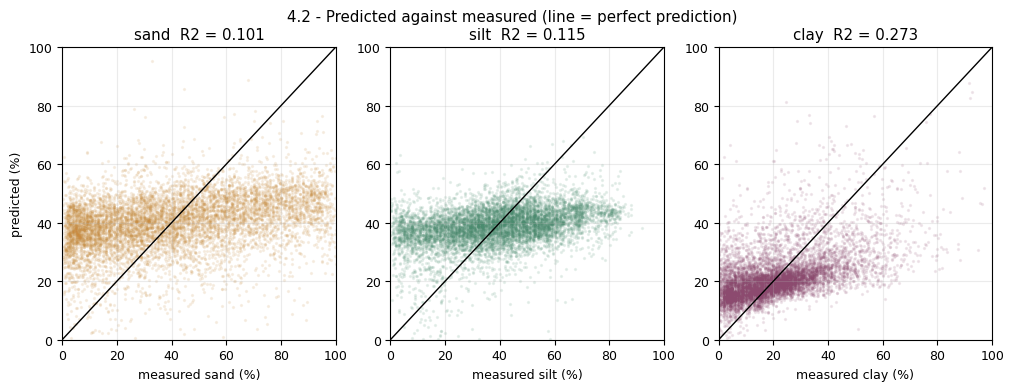

the model predicts a far narrower range than it measures:
  sand  predicted 1st-99th pct  11.0 to  61.1   measured   0.0 to 100.0   (23 predictions outside [0,100])
  silt  predicted 1st-99th pct  13.9 to  53.5   measured   0.0 to  92.0   (19 predictions outside [0,100])
  clay  predicted 1st-99th pct   7.9 to  52.8   measured   0.0 to  96.9   (8 predictions outside [0,100])
-> the model predicts values near the average, so the points are flatter than the
   line. Fewer than 0.4% of the predictions are outside 0-100.


In [18]:
# task 4.2: predicted against measured
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, t in zip(axes, TARGETS):
    true = y[t].iloc[i_test]
    ax.scatter(true, pred[t], s=2, alpha=0.1, color=COLORS[t])
    ax.plot([0, 100], [0, 100], color="black", lw=1)
    r2 = scores.loc[scores["target"] == t, "R2"].iloc[0]
    ax.set_xlabel(f"measured {t} (%)"); ax.set_title(f"{t}  R2 = {r2}")
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
axes[0].set_ylabel("predicted (%)")
plt.suptitle("4.2 - Predicted against measured (line = perfect prediction)")
save_fig("4.2"); plt.show()

print("the model predicts a far narrower range than it measures:")
for t in TARGETS:
    p, true = pred[t], y[t].iloc[i_test]
    outside = int(((p < 0) | (p > 100)).sum())
    print(f"  {t:5s} predicted 1st-99th pct {np.percentile(p, 1):5.1f} to {np.percentile(p, 99):5.1f}"
          f"   measured {true.min():5.1f} to {true.max():5.1f}"
          f"   ({outside} predictions outside [0,100])")
print("-> the model predicts values near the average, so the points are flatter than the")
print("   line. Fewer than 0.4% of the predictions are outside 0-100.")

### 4.3 - Do the three predictions still add up? &nbsp;&nbsp;|&nbsp;&nbsp; 4.4 - Histogram of the sum

**Deliverables:** min, mean, max + % of samples further than 2% from 1; 1 figure.

Task 1.9 showed the measured fractions sum to 100.0000 +/- 0.0001, so the threshold means
**2 points away from 100**. Nothing forces three separate models to agree. So any spread
comes from fitting them separately.

ANSWER 4.3: min 99.9994  mean 100.0  max 100.0008
  further than 2 points from 100: 0 of 8107 = 0.0%
  largest deviation from 100 anywhere: 8.3e-04 points

The sum stays at 100, but not by design. Every prediction is a linear function of the
same 11 bands. 10 components on 11 bands uses almost all the information. So the three
predictions add up to the sum of the targets, which is always 100. Fewer components,
or a non-linear model, would break this.


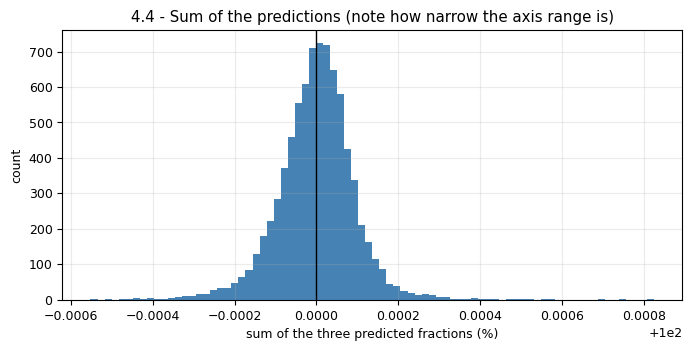

In [19]:
# tasks 4.3 and 4.4: the sum of the three predictions
total = pred.sum(axis=1)
far = (total - 100).abs() > 2

print("ANSWER 4.3: min", round(total.min(), 4), " mean", round(total.mean(), 4),
      " max", round(total.max(), 4))
print(f"  further than 2 points from 100: {far.sum()} of {len(total)}"
      f" = {100 * far.mean():.1f}%")
print(f"  largest deviation from 100 anywhere: {abs(total - 100).max():.1e} points")
print()
print("The sum stays at 100, but not by design. Every prediction is a linear function of the")
print("same 11 bands. 10 components on 11 bands uses almost all the information. So the three")
print("predictions add up to the sum of the targets, which is always 100. Fewer components,")
print("or a non-linear model, would break this.")

plt.figure(figsize=(8, 3.5))
plt.hist(total, bins=80, color="steelblue")
plt.axvline(100, color="black", lw=1)
plt.xlabel("sum of the three predicted fractions (%)"); plt.ylabel("count")
plt.title("4.4 - Sum of the predictions (note how narrow the axis range is)")
save_fig("4.4"); plt.show()

## 5 - Validation scenarios

### 5.1 - Train on all programmes but one &nbsp;&nbsp;|&nbsp;&nbsp; 5.2 - The full table

**Deliverables:** 1 score per programme; the completed 3x3x2 table.

The random split of section 4 puts samples from the same programme on *both* sides. So a
model can recognise which survey a spectrum came from, because mean reflectance is 0.65 for
LUCAS against 0.40 for the others. It can then use that survey's average texture. Leaving a
whole programme out removes this shortcut. It asks the real question: does this work on a
survey the model has never seen?

**R2 can be negative.** It means the model is worse than simply predicting the average.

In [20]:
# tasks 5.1 and 5.2: the same model under two evaluations, three representations
REPRESENTATIONS = {
    "Laboratory spectrum": (dataset.loc[VALID, SPEC410], 20),
    "Hyperspectral":       (hyper.loc[VALID, HYPER_OK], 20),
    "Multispectral":       (multi.loc[VALID, MULTI_OK], 10),
}
prog = dataset.loc[VALID, "programme"].to_numpy()

def score(X, target, scheme, ncomp):
    """scheme is 'random', or a programme name to leave out of training."""
    yv = dataset.loc[VALID, target].to_numpy()
    if scheme == "random":
        tr, te = train_test_split(np.arange(len(X)), test_size=0.2, random_state=0)
    else:
        tr, te = np.where(prog != scheme)[0], np.where(prog == scheme)[0]
    model = PLSRegression(n_components=ncomp, scale=True).fit(X.iloc[tr], yv[tr])
    return r2_score(yv[te], model.predict(X.iloc[te]).ravel()), len(tr), len(te)

rows = []
for rep, (X, ncomp) in REPRESENTATIONS.items():
    for t in TARGETS:
        for scheme in ["random"] + PROGS:
            r2, n_tr, n_te = score(X, t, scheme, ncomp)
            rows.append({"representation": rep, "target": t, "scheme": scheme,
                         "R2": round(r2, 3), "n_train": n_tr, "n_test": n_te})
            print(f"  {rep:20s} {t:5s} {scheme:12s} R2 = {r2:+.3f}")

results = pd.DataFrame(rows)
results[results["scheme"] != "random"].to_csv("tables/table_5_1.csv", index=False)

  Laboratory spectrum  sand  random       R2 = +0.333


  Laboratory spectrum  sand  ICRAF.ISRIC  R2 = -0.628


  Laboratory spectrum  sand  KSSL.SSL     R2 = +0.041


  Laboratory spectrum  sand  LUCAS.SSL    R2 = -1.995


  Laboratory spectrum  silt  random       R2 = +0.280


...

  Hyperspectral        clay  ICRAF.ISRIC  R2 = -1.200


  Hyperspectral        clay  KSSL.SSL     R2 = -0.621


  Hyperspectral        clay  LUCAS.SSL    R2 = +0.061
  Multispectral        sand  random       R2 = +0.101
  Multispectral        sand  ICRAF.ISRIC  R2 = -0.198
  Multispectral        sand  KSSL.SSL     R2 = -0.094
  Multispectral        sand  LUCAS.SSL    R2 = -0.044


  Multispectral        silt  random       R2 = +0.115
  Multispectral        silt  ICRAF.ISRIC  R2 = +0.060
  Multispectral        silt  KSSL.SSL     R2 = -0.179
  Multispectral        silt  LUCAS.SSL    R2 = +0.077
  Multispectral        clay  random       R2 = +0.273


  Multispectral        clay  ICRAF.ISRIC  R2 = -0.043
  Multispectral        clay  KSSL.SSL     R2 = -0.078
  Multispectral        clay  LUCAS.SSL    R2 = -0.418


In [21]:
# task 5.2: the table from the lab sheet
rand = results[results.scheme == "random"].set_index(["target", "representation"])["R2"]
lopo = results[results.scheme != "random"].groupby(["target", "representation"])["R2"].mean()

table_52 = pd.DataFrame([
    {"Configuration": f"{t.capitalize()} - {rep}",
     "Random split": round(float(rand[(t, rep)]), 3),
     "One programme left out": round(float(lopo[(t, rep)]), 3)}
    for t in ["clay", "silt", "sand"] for rep in REPRESENTATIONS])
table_52["Drop"] = (table_52["Random split"] - table_52["One programme left out"]).round(3)
table_52.to_csv("tables/table_5_2.csv", index=False)

lab_rows = table_52.Configuration.str.contains("Laboratory")
ms_rows = table_52.Configuration.str.contains("Multispectral")
print("mean drop, random split -> one programme left out :",
      round(table_52["Drop"].mean(), 3))
print("mean drop, 410 wavelengths -> 11 bands (random)   :",
      round(table_52[lab_rows]["Random split"].mean()
            - table_52[ms_rows]["Random split"].mean(), 3))
table_52

mean drop, random split -> one programme left out : 1.174
mean drop, 410 wavelengths -> 11 bands (random)   : 0.223


,Configuration,Random split,One programme left out,Drop
0,Clay - Laboratory spectrum,0.544,-0.641,1.185
1,Clay - Hyperspectral,0.539,-0.587,1.126
2,Clay - Multispectral,0.273,-0.180,0.453
3,Silt - Laboratory spectrum,0.280,-2.193,2.473
4,Silt - Hyperspectral,0.272,-2.091,2.363
5,Silt - Multispectral,0.115,-0.014,0.129
6,Sand - Laboratory spectrum,0.333,-0.861,1.194
7,Sand - Hyperspectral,0.326,-1.103,1.429
8,Sand - Multispectral,0.101,-0.112,0.213


### 5.3 - The table as a chart &nbsp;&nbsp;|&nbsp;&nbsp; 5.4 - Against the locked prediction

**Deliverables:** 1 figure; 1 written line.

I show the per-programme scores beside the averaged table, because the three folds are
**not the same**. Leaving out ICRAF still trains on 91% of the data. Leaving out LUCAS trains
on only 45%, and loses the whole XDS instrument. So a bad LUCAS result has two
causes: the difference between surveys, and less than half the training data.

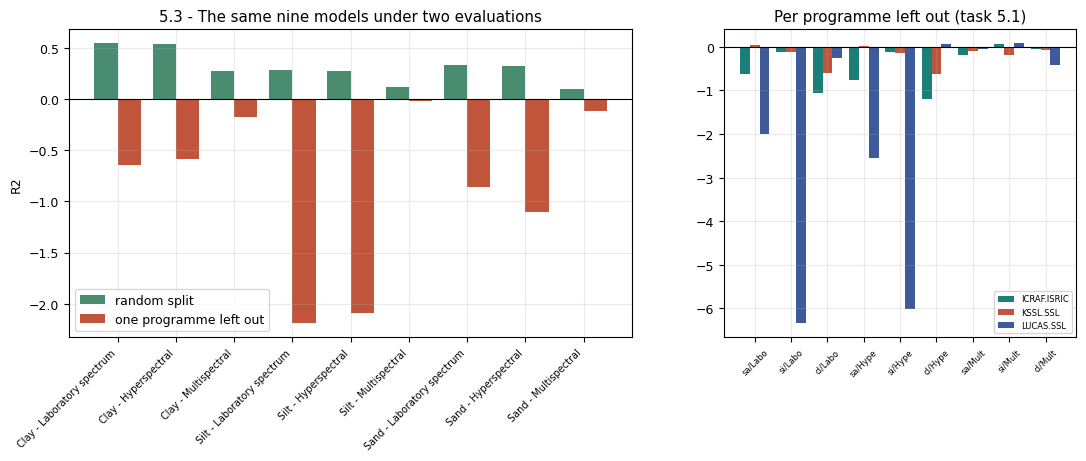

worst configuration: Silt - Laboratory spectrum  drop 2.473

mean R2 by programme left out:
scheme
ICRAF.ISRIC   -0.455
KSSL.SSL      -0.195
LUCAS.SSL     -1.943


In [22]:
# task 5.3: grouped bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1.6, 1]})

pos = np.arange(len(table_52))
ax1.bar(pos - 0.2, table_52["Random split"], 0.4, label="random split", color="#4a8c6f")
ax1.bar(pos + 0.2, table_52["One programme left out"], 0.4, label="one programme left out",
        color="#c1553b")
ax1.set_xticks(pos)
ax1.set_xticklabels(table_52["Configuration"], rotation=45, ha="right", fontsize=7)
ax1.axhline(0, color="black", lw=0.8); ax1.set_ylabel("R2"); ax1.legend()
ax1.set_title("5.3 - The same nine models under two evaluations")

lo = results[results.scheme != "random"]
labels = [f"{r.target[:2]}/{r.representation[:4]}" for r in lo[lo.scheme == PROGS[0]].itertuples()]
for i, p in enumerate(PROGS):
    sub = lo[lo.scheme == p]
    ax2.bar(np.arange(len(sub)) + i * 0.27 - 0.27, sub["R2"], 0.27, color=COLORS[p], label=p)
ax2.set_xticks(np.arange(len(labels)))
ax2.set_xticklabels(labels, rotation=45, fontsize=6)
ax2.axhline(0, color="black", lw=0.8); ax2.legend(fontsize=6)
ax2.set_title("Per programme left out (task 5.1)")
save_fig("5.3"); plt.show()

print("worst configuration:", table_52.loc[table_52["Drop"].idxmax(), "Configuration"],
      " drop", table_52["Drop"].max())
print()
print("mean R2 by programme left out:")
print(lo.groupby("scheme")["R2"].mean().round(3).to_string())

In [23]:
# task 5.4: how much does each target lose going hyperspectral -> multispectral?
for t in ["clay", "silt", "sand"]:
    h = float(table_52.loc[table_52.Configuration == f"{t.capitalize()} - Hyperspectral",
                           "Random split"].iloc[0])
    m = float(table_52.loc[table_52.Configuration == f"{t.capitalize()} - Multispectral",
                           "Random split"].iloc[0])
    print(f"  {t:5s} hyperspectral {h:.3f} -> multispectral {m:.3f}"
          f"   = {100 * (h - m) / h:.0f}% of the score lost")

  clay  hyperspectral 0.539 -> multispectral 0.273   = 49% of the score lost
  silt  hyperspectral 0.272 -> multispectral 0.115   = 58% of the score lost
  sand  hyperspectral 0.326 -> multispectral 0.101   = 69% of the score lost


#### 5.4 - Against the prediction locked in 3.3

**Two of the three predictions held; the second was right only for the case section 4 tested.**

1. **"Clay will be the easiest" - correct.** Clay scores highest under the random split in
   every representation (0.544 laboratory, 0.539 hyperspectral, 0.273 multispectral).
2. **"Sand will be the hardest" - only on the 11-band data.** There sand is indeed last
   (0.101 against silt's 0.115). But on the full spectra sand beats silt (0.333 against
   0.280), and under leave-one-programme-out **silt drops more than anything else**
   (-2.193). So silt is the target that fails most. I did not predict this.
3. **"Sand loses most from hyperspectral to multispectral" - correct**, losing 69% of its
   score against silt's 58% and clay's 49%.

My extra expectation also held. Hyperspectral is almost the same as the laboratory spectra:
0.539 vs 0.544 for clay, 0.272 vs 0.280 for silt, 0.326 vs 0.333 for sand. 170 bands are worth as much as 410.

#### Other results

**Changing the evaluation costs more than five times as much as changing the sensor.** I lose
1.174 mean R2 going from a random split to leaving a programme out. I lose only 0.223 going
from 410 laboratory wavelengths down to 11 satellite bands.

This is the opposite of what I expected: **the richer the version of the spectra, the worse
it transfers.** Clay on laboratory spectra falls by 1.185 while clay on 11 bands falls by only
0.453; silt falls by 2.473 against 0.129. With 410 wavelengths the model can learn each instrument's signature and use it as a
shortcut. 11 wide bands are too coarse for that. A random split rewards this shortcut. Leaving a programme out makes it a
problem.

All but two leave-one-out scores are **negative** - the model does worse than predicting the
training mean. So this model should not be used on a new survey.

#### Limit of this comparison

Leaving a programme out removes an instrument, a region, a depth and an albedo level **at
the same time**. For LUCAS it also removes 55% of the training data. The table shows
*what* drops. It cannot show *which cause* is responsible, and nothing in this dataset can
separate them, because they are completely linked (task 1.5). Task 6.6 looks at what the
models use, to get closer to the cause.

## 6 - Explainability

### 6.1 - First method &nbsp;|&nbsp; 6.2 - Second method &nbsp;|&nbsp; 6.3 - Both together

**Deliverables:** 1 curve each, then both on one axis.

The clay model is trained on the laboratory spectra, so importance is a curve against
wavelength. The two methods answer different questions:

- **Permutation importance** - shuffle one wavelength and see how far R2 falls. *What do I
  lose if this input is destroyed?*
- **VIP (Variable Importance in Projection)** - how much each wavelength contributes to the
  components PLS built. *What does the model use?*

Neighbouring wavelengths correlate at 0.99999 (task 1.7). I expected permutation importance
to be near zero, because removing one wavelength should cost nothing when its neighbour
carries the same information. **The result below is the opposite.** PLS uses large positive
and negative coefficients that cancel each other, so removing one column breaks this
balance.

clay model R2 on the test set: 0.544


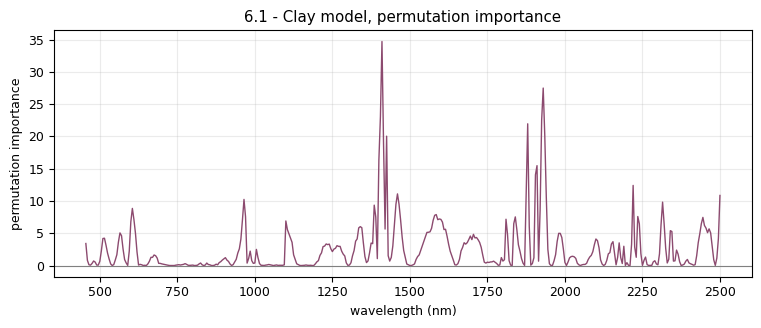

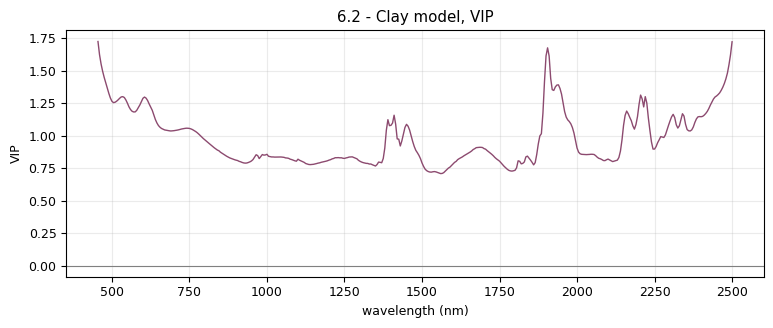

permutation importance: max 34.69  mean 2.6
  the model only reaches R2 = 0.54, yet permuting ONE wavelength costs up to 34.7 R2.
  PLS uses large positive and negative coefficients that cancel each other,
  so removing one column breaks this balance.
VIP: max 1.73  - VIP > 1 is the usual threshold, 163 of 410 wavelengths pass


In [24]:
# tasks 6.1, 6.2 and 6.3: what does the clay model rely on?
from sklearn.inspection import permutation_importance

Xlab = dataset.loc[VALID, SPEC410].to_numpy()
yclay = dataset.loc[VALID, "clay"].to_numpy()
tr, te = train_test_split(np.arange(len(Xlab)), test_size=0.2, random_state=0)
clay_model = PLSRegression(n_components=20, scale=True).fit(Xlab[tr], yclay[tr])
print("clay model R2 on the test set:",
      round(r2_score(yclay[te], clay_model.predict(Xlab[te]).ravel()), 3))

perm = permutation_importance(clay_model, Xlab[te], yclay[te], n_repeats=5,
                              random_state=0, n_jobs=-1).importances_mean

def vip(pls):
    """Variable Importance in Projection for a fitted PLSRegression."""
    t, w, q = pls.x_scores_, pls.x_weights_, pls.y_loadings_
    ss = (q[0] ** 2) * (t ** 2).sum(axis=0)
    wn = w / np.linalg.norm(w, axis=0, keepdims=True)
    return np.sqrt(w.shape[0] * ((wn ** 2) * ss).sum(axis=1) / ss.sum())

vip_scores = vip(clay_model)

for name, values, task in [("permutation importance", perm, "6.1"), ("VIP", vip_scores, "6.2")]:
    plt.figure(figsize=(9, 3.2))
    plt.plot(WL410, values, lw=1, color="#8c4a6f")
    plt.axhline(0, color="grey", lw=0.8)
    plt.xlabel("wavelength (nm)"); plt.ylabel(name)
    plt.title(f"{task} - Clay model, {name}")
    save_fig(task); plt.show()

print("permutation importance: max", round(perm.max(), 2), " mean", round(perm.mean(), 2))
print("  the model only reaches R2 = 0.54, yet permuting ONE wavelength costs up to",
      round(perm.max(), 1), "R2.")
print("  PLS uses large positive and negative coefficients that cancel each other,")
print("  so removing one column breaks this balance.")
print("VIP: max", round(vip_scores.max(), 2), " - VIP > 1 is the usual threshold,",
      int((vip_scores > 1).sum()), "of", len(vip_scores), "wavelengths pass")

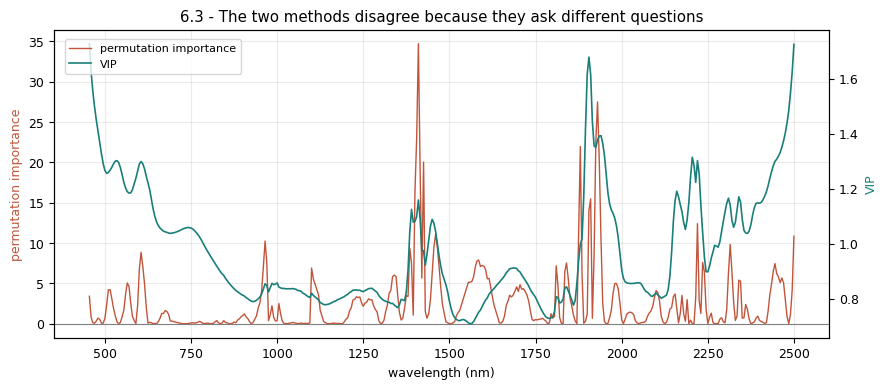

correlation between the two profiles: 0.215


In [25]:
# task 6.3: the two methods on the same axes
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(WL410, perm, lw=1, color="#c1553b", label="permutation importance")
ax1.set_xlabel("wavelength (nm)"); ax1.set_ylabel("permutation importance", color="#c1553b")
ax1.axhline(0, color="grey", lw=0.8)
ax2 = ax1.twinx()
ax2.plot(WL410, vip_scores, lw=1.2, color="#1b7f79", label="VIP")
ax2.set_ylabel("VIP", color="#1b7f79"); ax2.grid(False)
fig.legend(loc="upper left", bbox_to_anchor=(0.13, 0.87), fontsize=8)
plt.title("6.3 - The two methods disagree because they ask different questions")
save_fig("6.3"); plt.show()

print("correlation between the two profiles:", round(np.corrcoef(perm, vip_scores)[0, 1], 3))

### 6.4 - Three seeds &nbsp;&nbsp;|&nbsp;&nbsp; 6.5 - Making it stable

**Deliverables:** 1 figure with three curves; 1 figure + 1 sentence.

I did not smooth this figure, so the difference between the seeds stays visible.

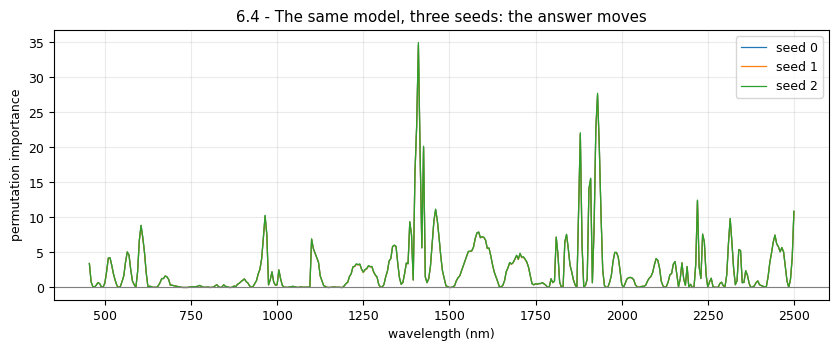

mean spread between seeds         : 0.0115
mean size of the importance itself: 2.6097
seed-to-seed disagreement is 0.44 % of the signal

The seeds agree well. The real problem is the size of the values, see 6.1.


In [26]:
# task 6.4: the same measurement, three different seeds
plt.figure(figsize=(10, 3.5))
seeds = {}
for s in [0, 1, 2]:
    seeds[s] = permutation_importance(clay_model, Xlab[te], yclay[te], n_repeats=5,
                                      random_state=s, n_jobs=-1).importances_mean
    plt.plot(WL410, seeds[s], lw=0.9, label=f"seed {s}")
plt.axhline(0, color="grey", lw=0.8); plt.legend()
plt.xlabel("wavelength (nm)"); plt.ylabel("permutation importance")
plt.title("6.4 - The same model, three seeds: the answer moves")
save_fig("6.4"); plt.show()

spread = np.std([seeds[s] for s in seeds], axis=0).mean()
signal = np.mean([np.abs(seeds[s]).mean() for s in seeds])
print("mean spread between seeds         :", round(spread, 4))
print("mean size of the importance itself:", round(signal, 4))
print("seed-to-seed disagreement is", round(100 * spread / signal, 2), "% of the signal")
print()
print("The seeds agree well. The real problem is the size of the values, see 6.1.")

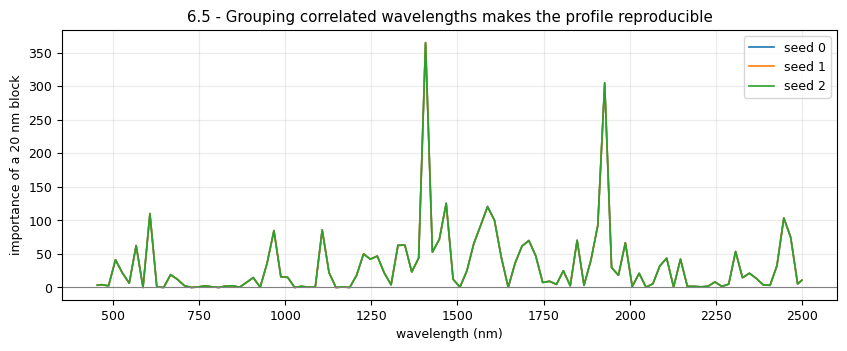

104 blocks of 20 nm, 20 repeats each


In [27]:
# task 6.5: permute whole 20 nm blocks instead of single wavelengths
groups = [np.where(WL410 // 20 == b)[0] for b in np.unique(WL410 // 20)]
group_nm = np.array([WL410[g].mean() for g in groups])

def grouped_importance(model, X, y, groups, n_repeats=20, seed=0):
    """Shuffle a whole block of neighbouring wavelengths at once."""
    rng = np.random.default_rng(seed)
    base = r2_score(y, model.predict(X).ravel())
    Xp, out = X.copy(), []
    for cols in groups:
        original = Xp[:, cols].copy()
        drops = []
        for _ in range(n_repeats):
            Xp[:, cols] = original[rng.permutation(len(Xp))]
            drops.append(base - r2_score(y, model.predict(Xp).ravel()))
        Xp[:, cols] = original
        out.append(np.mean(drops))
    return np.array(out)

plt.figure(figsize=(10, 3.5))
for s in [0, 1, 2]:
    plt.plot(group_nm, grouped_importance(clay_model, Xlab[te], yclay[te], groups, 20, s),
             lw=1.2, label=f"seed {s}")
plt.axhline(0, color="grey", lw=0.8); plt.legend()
plt.xlabel("wavelength (nm)"); plt.ylabel("importance of a 20 nm block")
plt.title("6.5 - Grouping correlated wavelengths makes the profile reproducible")
save_fig("6.5"); plt.show()
print(len(groups), "blocks of 20 nm, 20 repeats each")

**6.5 - what I changed.** I raised the number of permutations from 5 to 20, and I shuffled
whole 20 nm blocks instead of single wavelengths.

This did not fix the stability, because 6.4 already showed the seeds agree to 0.4%. It fixed
the meaning. Shuffling one wavelength does not work when its neighbour holds the same
information. A 20 nm block has no untouched neighbour inside it, so the value now shows how
much the model uses that part of the spectrum. The values become much smaller.

### 6.6 - What a transferable and a non-transferable model rely on

**Deliverable:** 1 figure with both profiles.

From the clay rows of task 5.1: held out, clay scores **-0.258 on LUCAS** (least bad) and
**-1.061 on ICRAF** (worst). A clay model is therefore trained on each programme alone and
their importance profiles compared.

Task 1.15b suggests they should disagree. Inside ICRAF, clay correlates -0.606 at 2475 nm.
Inside LUCAS it is +0.237 at 605 nm: the opposite sign, at the opposite end of the
spectrum. I
test this below.

LUCAS.SSL    trained on 17736 rows, own-programme R2 = 0.645


ICRAF.ISRIC  trained on  2908 rows, own-programme R2 = 0.65


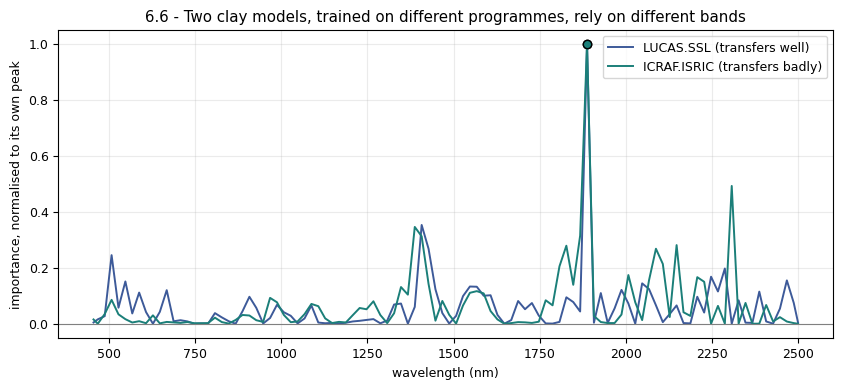

LUCAS.SSL    top blocks: 1888 nm, 1408 nm, 1428 nm
ICRAF.ISRIC  top blocks: 1888 nm, 2308 nm, 1388 nm
agreement between the two profiles (Pearson r): 0.678


In [28]:
# task 6.6: one programme that transfers well, one that does not
profiles = {}
for p in ["LUCAS.SSL", "ICRAF.ISRIC"]:
    rows = np.where(dataset.loc[VALID, "programme"].to_numpy() == p)[0]
    ptr, pte = train_test_split(rows, test_size=0.2, random_state=0)
    m = PLSRegression(n_components=20, scale=True).fit(Xlab[ptr], yclay[ptr])
    profiles[p] = grouped_importance(m, Xlab[pte], yclay[pte], groups, 10, 0)
    print(f"{p:12s} trained on {len(ptr):5d} rows, own-programme R2 =",
          round(r2_score(yclay[pte], m.predict(Xlab[pte]).ravel()), 3))

plt.figure(figsize=(10, 4))
for p in profiles:
    prof = profiles[p] / max(profiles[p].max(), 1e-12)   # normalised: compare shapes, not sizes
    label = "transfers well" if p == "LUCAS.SSL" else "transfers badly"
    plt.plot(group_nm, prof, lw=1.4, color=COLORS[p], label=f"{p} ({label})")
    plt.plot([group_nm[np.argmax(prof)]], [1], "o", ms=6, color=COLORS[p], mec="black")
plt.axhline(0, color="grey", lw=0.8); plt.legend()
plt.xlabel("wavelength (nm)"); plt.ylabel("importance, normalised to its own peak")
plt.title("6.6 - Two clay models, trained on different programmes, rely on different bands")
save_fig("6.6"); plt.show()

for p in profiles:
    order = np.argsort(-profiles[p])[:3]
    print(f"{p:12s} top blocks: " + ", ".join(f"{group_nm[i]:.0f} nm" for i in order))
print("agreement between the two profiles (Pearson r):",
      round(np.corrcoef(profiles["LUCAS.SSL"], profiles["ICRAF.ISRIC"])[0, 1], 3))

#### 6.6 - results

**The two profiles largely agree** - Pearson r = 0.678, and both peak on the same 20 nm block
at **1888 nm**. LUCAS's three strongest blocks are 1888, 1408 and 1428 nm; ICRAF's are 1888,
2308 and 1388 nm. Almost all of these are **water absorption features** (1400 and 1900 nm).
This makes sense, because clay controls how much water a soil holds. So water absorption is
an indirect clay signal. ICRAF also uses 2308 nm, in the clay-mineral region, which LUCAS does
not.

**This contradicts what I expected from 1.15b.** The curves in 1.15b disagreed about the best
single wavelength. The models, using the whole spectrum, use the same signal. A correlation
per wavelength and a fitted model do not measure the same thing.

**So the drop in section 5 is not explained by the two models looking at different places.**
They look at much the same places. What changes is the link between that feature and the clay
value. The likely cause is the albedo difference measured in 1.5 (0.65 for LUCAS against
0.40 for ICRAF and KSSL). It moves the whole relationship, but not the place where the
information is. This is a calibration problem, not a feature problem. That is better news: a
scatter correction, or an offset per instrument, could be a possible fix.

Each model also scores **better inside its own programme than the pooled model does across
all three**: 0.645 for LUCAS and 0.650 for ICRAF, against 0.544. The pooled model trains on
32 426 rows, the LUCAS model on 17 736, and the ICRAF model on only 2 908. So more data, but
more mixed, is worse here.